# Plot KSG MI Results — shendure / SCVI only

Reads `ksg_mutual_information.txt` files written by
`2026-04-20_10-49_compute_ksg_scaling_curves.py` and the stored
`lmi_mutual_information.txt` files (seed 42) for every
(size, quality) combination on **shendure** with **SCVI**.

Plot set adapted from `2026-04-20_12-45_plotting_ksg_scvi_verify.ipynb`:
- Side-by-side MI vs quality (KSG in bits | LMI in nats), one curve per size.
- KSG vs LMI scatter (both in bits) with linear fit and correlation diagnostics.

Save paths mirror `2026-04-20_10-49_compute_ksg_scaling_curves.py`.

In [7]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

DATA_ROOT = Path('/home/igor/noise_scaling/data')
DATASET = 'shendure'
ALGO = 'SCVI'
SIGNAL = 'author_day'
SEED = 42

# shendure grid (mirrors compute script)
SIZES = [100, 359, 1291, 4641, 16681, 59948, 215443, 774263, 2782559, 10000000]
QUALITIES = [0.004, 0.0073875, 0.0136438, 0.0251984, 0.0465384,
             0.0859506, 0.1587401, 0.2931733, 0.5414548, 1.0]

## Path helpers — mirror `2026-04-20_10-49_compute_ksg_scaling_curves.py`

In [8]:
def embeddings_dir(dataset, size, quality, algorithm):
    return DATA_ROOT / dataset / str(size) / str(quality) / 'results' / algorithm / 'model'

def ksg_output_path(dataset, size, quality, algorithm, signal_stem):
    return (embeddings_dir(dataset, size, quality, algorithm)
            / 'MI' / 'ksg' / signal_stem / 'ksg_mutual_information.txt')

def lmi_value_path(dataset, size, quality, algorithm, signal_stem, seed=SEED):
    return (embeddings_dir(dataset, size, quality, algorithm)
            / 'MI' / str(seed) / signal_stem / 'lmi_mutual_information.txt')

## Scan disk: read KSG (bits) and LMI (nats, seed 42)

In [9]:
def _read_float(path):
    try:
        with open(path) as f:
            return float(f.read().strip())
    except Exception:
        return np.nan

suffix = '_geneformer' if ALGO == 'Geneformer' else ''

rows = []
for sz, q in product(SIZES, QUALITIES):
    stem = f'Y_{SIGNAL}_{q}{suffix}'
    rows.append({
        'dataset': DATASET, 'algorithm': ALGO, 'signal': SIGNAL,
        'size': sz, 'quality': q,
        'ksg_path': str(ksg_output_path(DATASET, sz, q, ALGO, stem)),
        'lmi_path': str(lmi_value_path(DATASET, sz, q, ALGO, stem, SEED)),
    })

df = pd.DataFrame(rows)
print(f'Total expected: {len(df)}')

with ThreadPoolExecutor(max_workers=128) as pool:
    df['ksg_exists'] = list(tqdm(pool.map(os.path.exists, df['ksg_path']),
                                 total=len(df), desc='scan ksg'))
    df['lmi_exists'] = list(tqdm(pool.map(os.path.exists, df['lmi_path']),
                                 total=len(df), desc='scan lmi'))

with ThreadPoolExecutor(max_workers=128) as pool:
    df['ksg_bits'] = list(tqdm(pool.map(_read_float, df['ksg_path']),
                               total=len(df), desc='read ksg'))
    df['lmi_nats_stored'] = list(tqdm(pool.map(_read_float, df['lmi_path']),
                                      total=len(df), desc='read lmi'))

print(f"KSG found: {int(df['ksg_exists'].sum())} / {len(df)}")
print(f"LMI found: {int(df['lmi_exists'].sum())} / {len(df)}")

df = df.sort_values(['size', 'quality']).reset_index(drop=True)
df

Total expected: 100


read lmi: 100%|██████████| 100/100 [00:00<00:00, 271475.99it/s]

KSG found: 100 / 100
LMI found: 100 / 100


,dataset,algorithm,signal,size,quality,ksg_path,lmi_path,ksg_exists,lmi_exists,ksg_bits,lmi_nats_stored
0,shendure,SCVI,author_day,100,0.004000,/home/igor/noise_scaling/data/shendure/100/0.0...,/home/igor/noise_scaling/data/shendure/100/0.0...,True,True,0.050254,0.05728
1,shendure,SCVI,author_day,100,0.007387,/home/igor/noise_scaling/data/shendure/100/0.0...,/home/igor/noise_scaling/data/shendure/100/0.0...,True,True,0.082650,0.06279
2,shendure,SCVI,author_day,100,0.013644,/home/igor/noise_scaling/data/shendure/100/0.0...,/home/igor/noise_scaling/data/shendure/100/0.0...,True,True,0.165465,0.15200
3,shendure,SCVI,author_day,100,0.025198,/home/igor/noise_scaling/data/shendure/100/0.0...,/home/igor/noise_scaling/data/shendure/100/0.0...,True,True,0.291045,0.26866
4,shendure,SCVI,author_day,100,0.046538,/home/igor/noise_scaling/data/shendure/100/0.0...,/home/igor/noise_scaling/data/shendure/100/0.0...,True,True,0.484121,0.45637
...,...,...,...,...,...,...,...,...,...,...,...
95,shendure,SCVI,author_day,10000000,0.085951,/home/igor/noise_scaling/data/shendure/1000000...,/home/igor/noise_scaling/data/shendure/1000000...,True,True,0.149640,1.74882
96,shendure,SCVI,author_day,10000000,0.158740,/home/igor/noise_scaling/data/shendure/1000000...,/home/igor/noise_scaling/data/shendure/1000000...,True,True,0.188789,1.99694
97,shendure,SCVI,author_day,10000000,0.293173,/home/igor/noise_scaling/data/shendure/1000000...,/home/igor/noise_scaling/data/shendure/1000000...,True,True,0.223376,2.23359
98,shendure,SCVI,author_day,10000000,0.541455,/home/igor/noise_scaling/data/shendure/1000000...,/home/igor/noise_scaling/data/shendure/1000000...,True,True,1.578685,2.14148


## Completeness check

In [10]:
completeness = pd.DataFrame({
    'expected': [len(df)],
    'ksg_found': [int(df['ksg_exists'].sum())],
    'ksg_missing': [int((~df['ksg_exists']).sum())],
    'lmi_found': [int(df['lmi_exists'].sum())],
    'lmi_missing': [int((~df['lmi_exists']).sum())],
}, index=[f'{DATASET} / {ALGO}'])
display(completeness)

,expected,ksg_found,ksg_missing,lmi_found,lmi_missing
shendure / SCVI,100,100,0,100,0


## Plots

### MI vs quality, one curve per size (KSG | LMI side-by-side)

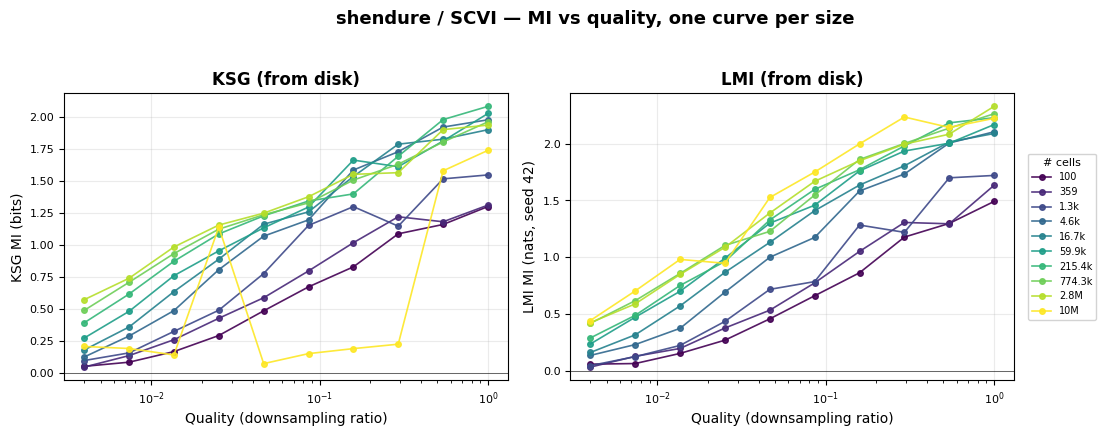

In [11]:
# KSG (bits) vs quality, next to LMI (nats) vs quality. One line per size.
# Styling: viridis cmap with LogNorm over sizes, '# cells' legend on the right.
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def _fmt_size(sz):
    if sz >= 1_000_000:
        return f'{sz/1_000_000:.0f}M' if sz % 1_000_000 == 0 else f'{sz/1_000_000:.1f}M'
    if sz >= 1_000:
        return f'{sz/1_000:.0f}k' if sz % 1_000 == 0 else f'{sz/1_000:.1f}k'
    return str(sz)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharex=True)
cmap = plt.cm.viridis
sizes_sorted = sorted(df['size'].unique())
norm = mcolors.LogNorm(vmin=min(sizes_sorted), vmax=max(sizes_sorted))

for s in sizes_sorted:
    sub = df[df['size'] == s].sort_values('quality')
    color = cmap(norm(s))
    axes[0].plot(sub['quality'], sub['ksg_bits'], marker='o', markersize=4,
                 linewidth=1.2, color=color, alpha=0.9, label=_fmt_size(s))
    axes[1].plot(sub['quality'], sub['lmi_nats_stored'], marker='o', markersize=4,
                 linewidth=1.2, color=color, alpha=0.9, label=_fmt_size(s))

for ax, ylab, title in [
    (axes[0], 'KSG MI (bits)', 'KSG (from disk)'),
    (axes[1], 'LMI MI (nats, seed 42)', 'LMI (from disk)'),
]:
    ax.set_xscale('log')
    ax.set_xlabel('Quality (downsampling ratio)', fontsize=10)
    ax.set_ylabel(ylab, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axhline(0, color='k', lw=0.4)
    ax.grid(alpha=0.25)
    ax.tick_params(labelsize=8)

axes[1].legend(title='# cells', fontsize=7, title_fontsize=8,
               loc='center left', bbox_to_anchor=(1.02, 0.5),
               frameon=True, framealpha=0.85)

fig.suptitle(f'{DATASET} / {ALGO} — MI vs quality, one curve per size',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()

### KSG vs LMI scatter (both in bits, with linear fit + correlation)

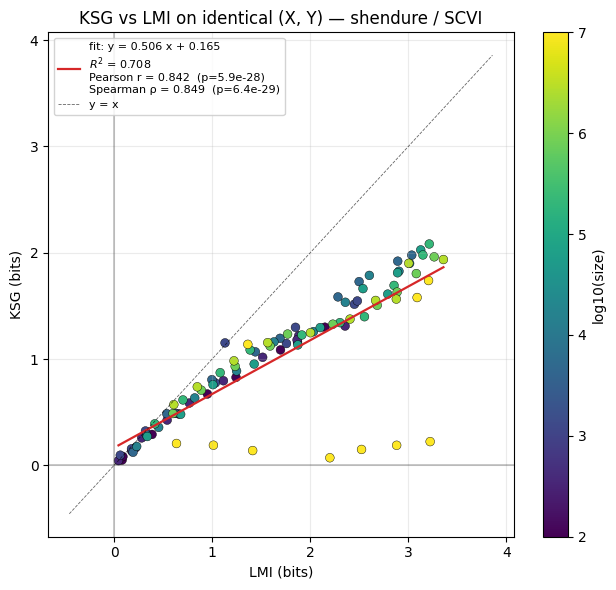

n = 100   slope = 0.5058   intercept = 0.1652
R^2 = 0.7082   Pearson r = 0.8415 (p=5.877e-28)   Spearman ρ = 0.8491 (p=6.391e-29)


In [12]:
# KSG vs LMI (both in bits) with linear fit + correlation diagnostics.
# y = slope*x + intercept, plus R^2 of that fit, Pearson r, and Spearman rho.
from scipy.stats import pearsonr, spearmanr

df_ok = df.dropna(subset=['lmi_nats_stored', 'ksg_bits']).copy()
df_ok['lmi_bits'] = df_ok['lmi_nats_stored'] / np.log(2)

x = df_ok['lmi_bits'].values
y = df_ok['ksg_bits'].values

slope, intercept = np.polyfit(x, y, 1)
y_hat = slope * x + intercept
ss_res = float(np.sum((y - y_hat) ** 2))
ss_tot = float(np.sum((y - y.mean()) ** 2))
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float('nan')
r_p, p_p = pearsonr(x, y)
r_s, p_s = spearmanr(x, y)

fig, ax = plt.subplots(figsize=(6.5, 6))
sc = ax.scatter(x, y, c=np.log10(df_ok['size']), cmap='viridis',
                s=40, edgecolor='k', linewidth=0.3)

x_line = np.linspace(float(x.min()), float(x.max()), 100)
fit_label = (f'fit: y = {slope:.3f} x + {intercept:.3f}\n'
             f'$R^2$ = {r2:.3f}\n'
             f'Pearson r = {r_p:.3f}  (p={p_p:.1e})\n'
             f'Spearman ρ = {r_s:.3f}  (p={p_s:.1e})')
ax.plot(x_line, slope * x_line + intercept, '-', color='C3', lw=1.6, label=fit_label)

lims = [min(x.min(), y.min()) - 0.5, max(x.max(), y.max()) + 0.5]
ax.plot(lims, lims, 'k--', lw=0.6, alpha=0.6, label='y = x')

ax.set_xlabel('LMI (bits)')
ax.set_ylabel('KSG (bits)')
ax.set_title(f'KSG vs LMI on identical (X, Y) — {DATASET} / {ALGO}')
ax.axhline(0, color='k', lw=0.3)
ax.axvline(0, color='k', lw=0.3)
plt.colorbar(sc, label='log10(size)', ax=ax)
ax.legend(loc='upper left', fontsize=8, frameon=True, framealpha=0.85)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f'n = {len(df_ok)}   slope = {slope:.4f}   intercept = {intercept:.4f}')
print(f'R^2 = {r2:.4f}   Pearson r = {r_p:.4f} (p={p_p:.3e})   Spearman ρ = {r_s:.4f} (p={p_s:.3e})')